In [1]:
"""
Example: Game Mechanics Analysis Pipeline
==========================================

Demonstrates the full 3-stage pipeline using SYNTHETIC data.
No API key or Julia installation required.

Run:
    python example_mechanics_analysis.py

Pipeline Variable Mapping
--------------------------
    Predictor (X):
        attacker_karyoku  -- Attacker's firepower stat
        defender_soukou   -- Defender's armor stat (multi-variable mode)

    Target (Y):
        damage  -- Integer damage dealt per hit

    Controls:
        cl      -- Hit type (0=miss, 1=hit, 2=critical)
        at_type -- Attack type code

    Ground-Truth Formula (known for validation):
        Pre-cap:   base = floor(karyoku * 1.5 + 5)
        Post-cap:  if base > 180: base = 180 + sqrt(base - 180)
        Critical:  base * 1.5
        Damage:    floor((base - soukou * rand) * ammo_rand)
"""

"\nExample: Game Mechanics Analysis Pipeline\n==========================================\n\nDemonstrates the full 3-stage pipeline using SYNTHETIC data.\nNo API key or Julia installation required.\n\nRun:\n    python example_mechanics_analysis.py\n\nPipeline Variable Mapping\n--------------------------\n    Predictor (X):\n        attacker_karyoku  -- Attacker's firepower stat\n        defender_soukou   -- Defender's armor stat (multi-variable mode)\n\n    Target (Y):\n        damage  -- Integer damage dealt per hit\n\n    Controls:\n        cl      -- Hit type (0=miss, 1=hit, 2=critical)\n        at_type -- Attack type code\n\n    Ground-Truth Formula (known for validation):\n        Pre-cap:   base = floor(karyoku * 1.5 + 5)\n        Post-cap:  if base > 180: base = 180 + sqrt(base - 180)\n        Critical:  base * 1.5\n        Damage:    floor((base - soukou * rand) * ammo_rand)\n"

In [2]:
from __future__ import annotations

In [3]:
import os
import sys

In [4]:
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.getcwd()
_ROOT = os.path.dirname(os.path.dirname(_HERE))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

In [5]:
import numpy as np
import pandas as pd

In [6]:
def run_single_variable_demo() -> None:
    """Demo 1: Single-variable analysis (karyoku -> damage)."""
    import matplotlib.pyplot as plt
    import matplotlib.pyplot as plt

    from analysis.data_loader import generate_synthetic_data
    from analysis.analyzer import GameMechanicsAnalyzer

    print("=" * 70)
    print("  Demo 1: Single-Variable Analysis")
    print("  X = attacker_karyoku -> Y = damage")
    print("=" * 70)
    print()

    df = generate_synthetic_data(n_samples=8000, seed=42, cap_value=180)
    df_hits = df[df["cl"] == 1].copy()
    print(f"Data: {len(df_hits)} normal-hit records")
    print(f"  attacker_karyoku range: [{df_hits['attacker_karyoku'].min()}, "
          f"{df_hits['attacker_karyoku'].max()}]")
    print(f"  damage range:           [{df_hits['damage'].min()}, "
          f"{df_hits['damage'].max()}]")
    print()

    analyzer = GameMechanicsAnalyzer(
        min_samples=3, min_segment_length=8, cap_penalty_scale=5.0,
    )
    result = analyzer.fit_and_discover(
        df_hits, x_cols="attacker_karyoku", y_col="damage",
    )

    print()
    print(analyzer.summary())

    save_dir = os.path.join(_HERE, "output")
    os.makedirs(save_dir, exist_ok=True)
    analyzer.plot_results(save_path=os.path.join(save_dir, "single_var_analysis.png"))
    print(f"Plot saved to: {save_dir}/single_var_analysis.png")

In [7]:
def run_multi_variable_demo() -> None:
    """Demo 2: Multi-variable analysis (karyoku + soukou -> damage)."""
    import matplotlib.pyplot as plt
    import matplotlib.pyplot as plt

    from analysis.data_loader import generate_synthetic_data
    from analysis.analyzer import GameMechanicsAnalyzer

    print()
    print("=" * 70)
    print("  Demo 2: Multi-Variable Analysis")
    print("  X = [attacker_karyoku, defender_soukou] -> Y = damage")
    print("=" * 70)
    print()

    df = generate_synthetic_data(n_samples=8000, seed=42, cap_value=180)
    df_hits = df[df["cl"] == 1].copy()
    print(f"Data: {len(df_hits)} normal-hit records")
    print(f"  attacker_karyoku range: [{df_hits['attacker_karyoku'].min()}, "
          f"{df_hits['attacker_karyoku'].max()}]")
    print(f"  defender_soukou range:  [{df_hits['defender_soukou'].min()}, "
          f"{df_hits['defender_soukou'].max()}]")
    print(f"  damage range:           [{df_hits['damage'].min()}, "
          f"{df_hits['damage'].max()}]")
    print()

    analyzer = GameMechanicsAnalyzer(
        min_samples=3, min_segment_length=8, cap_penalty_scale=5.0,
    )
    result = analyzer.fit_and_discover(
        df_hits,
        x_cols=["attacker_karyoku", "defender_soukou"],
        y_col="damage",
    )

    print()
    print(analyzer.summary())

    save_dir = os.path.join(_HERE, "output")
    os.makedirs(save_dir, exist_ok=True)
    analyzer.plot_results(save_path=os.path.join(save_dir, "multi_var_analysis.png"))
    print(f"Plot saved to: {save_dir}/multi_var_analysis.png")

  Demo 1: Single-Variable Analysis
  X = attacker_karyoku -> Y = damage

Data: 5675 normal-hit records
  attacker_karyoku range: [30, 299]
  damage range:           [0, 156]

=== Stage 1: NoiseFilter ===
  Predictor(s) (X): ['attacker_karyoku']
    Primary variable for cap detection: attacker_karyoku
  Target (Y): damage
  Extracting 99% / 1% percentiles ...
  -> 270 unique X-groups after filtering.

=== Stage 2: CapDetector ===
  Detecting slope changes in Y_max(attacker_karyoku) ...
  Method: gradient
  -> Caps detected at attacker_karyoku = [71, 108, 135, 151]
  -> 5 segment(s).

=== Stage 3: FormulaDiscoverer ===
  Segment 0: attacker_karyoku in [30, 70] (41 points)
    Formula: floor(-0.008847*attacker_karyoku^2 + 2.377214*attacker_karyoku + -60.471464)
    MAE=3.028, MaxErr=11.000, Exact=2.4%
    Method: polyfit(deg=2)

  Segment 1: attacker_karyoku in [71, 107] (37 points)
    Formula: floor(1.512326*attacker_karyoku + -42.854289)
    MAE=3.812, MaxErr=17.000, Exact=5.4%
    Met

C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:252: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(


Figure saved to C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\examples\output\single_var_analysis.png


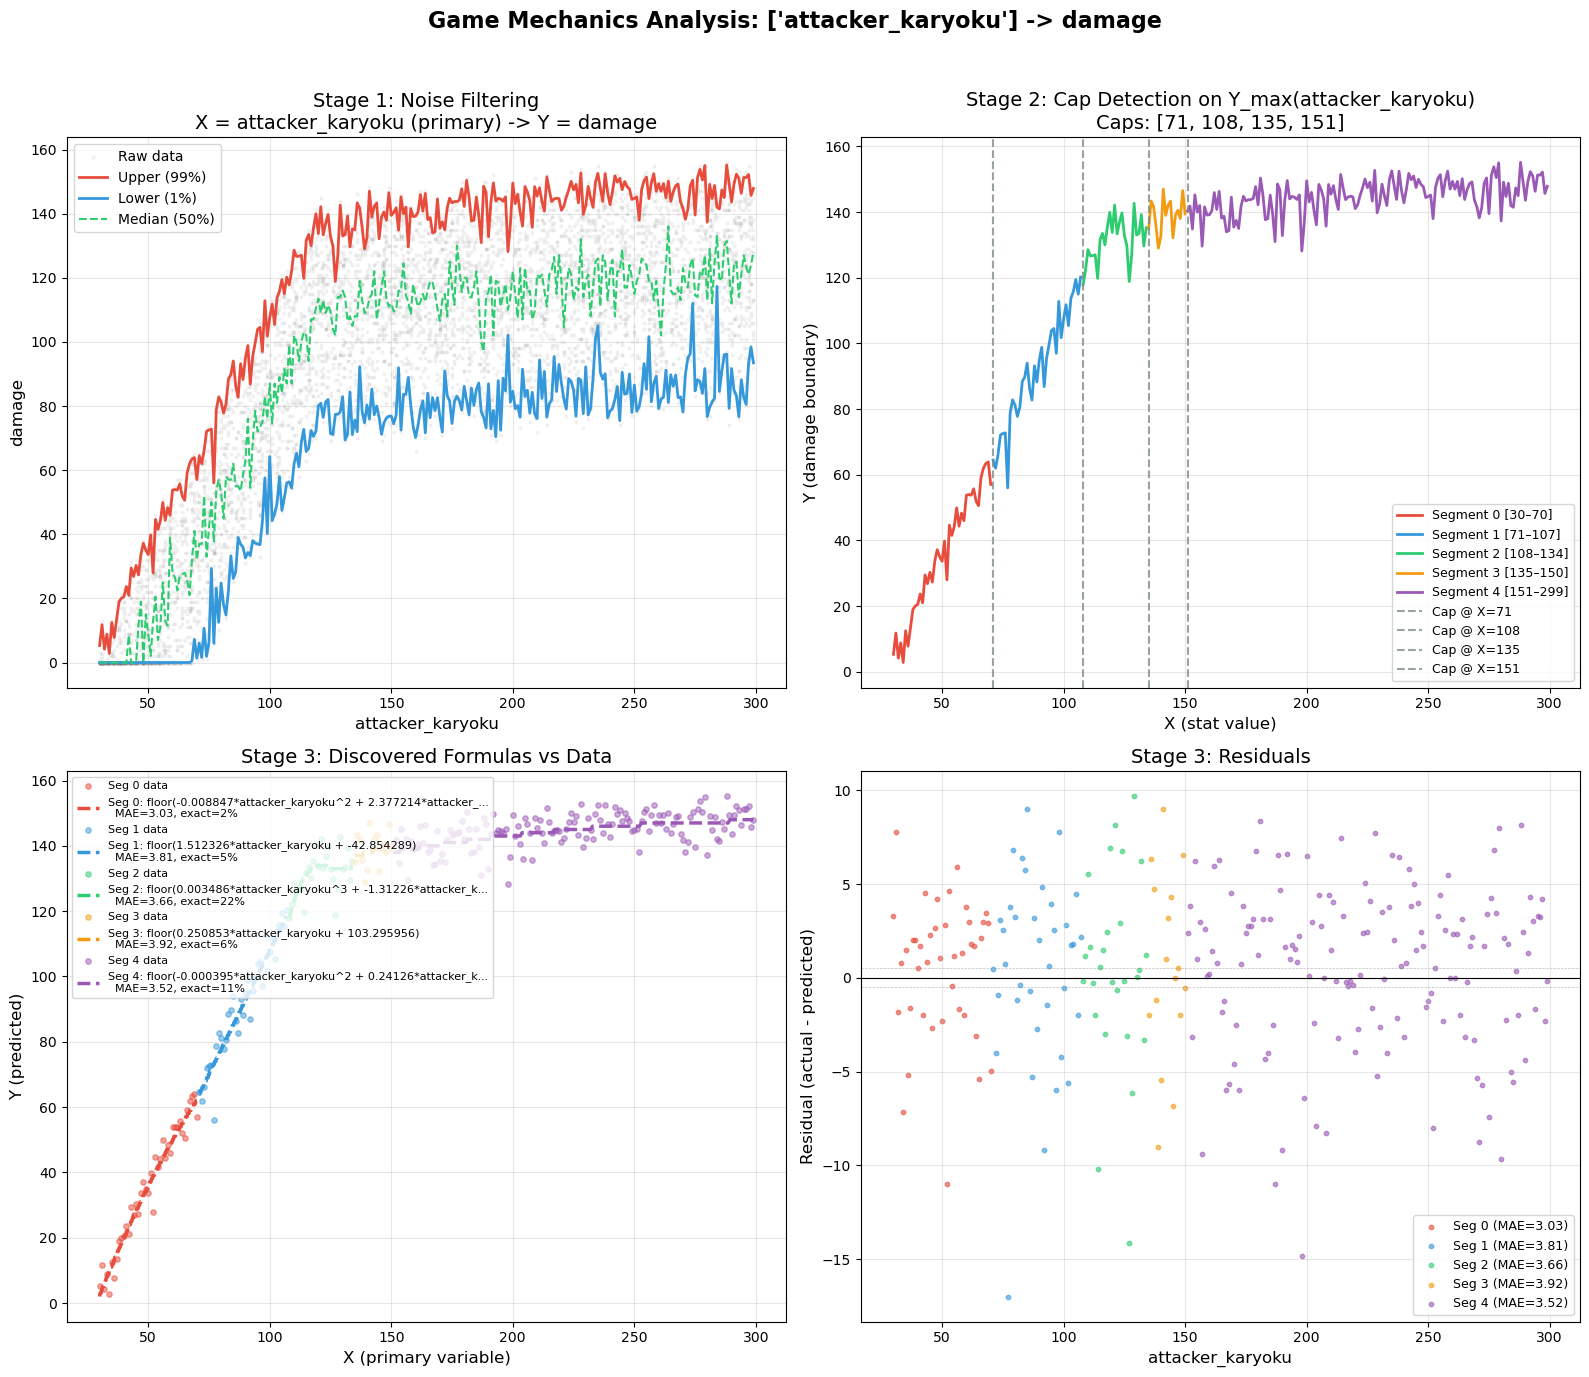

Plot saved to: C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\examples\output/single_var_analysis.png

  Demo 2: Multi-Variable Analysis
  X = [attacker_karyoku, defender_soukou] -> Y = damage

Data: 5675 normal-hit records
  attacker_karyoku range: [30, 299]
  defender_soukou range:  [50, 119]
  damage range:           [0, 156]

=== Stage 1: NoiseFilter ===
  Predictor(s) (X): ['attacker_karyoku', 'defender_soukou']
    Primary variable for cap detection: attacker_karyoku
    Additional variables for formula: ['defender_soukou']
  Target (Y): damage
  Extracting 99% / 1% percentiles ...
  -> 270 unique X-groups after filtering.

=== Stage 2: CapDetector ===
  Detecting slope changes in Y_max(attacker_karyoku) ...
  Method: gradient
  -> Caps detected at attacker_karyoku = [71, 108, 135, 151]
  -> 5 segment(s).

=== Stage 3: FormulaDiscoverer ===
  Using 2 input variables: ['attacker_karyoku', 'defender_soukou']
  Segment 0: attacker_karyoku in [30, 70] (41 points)
    F

C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr'); falling back to regression.
  result = self.formula_discoverer.discover(
C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\analysis\analyzer.py:245: RuntimeWarning: PySR failed (No module named 'pysr')

Figure saved to C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\examples\output\multi_var_analysis.png


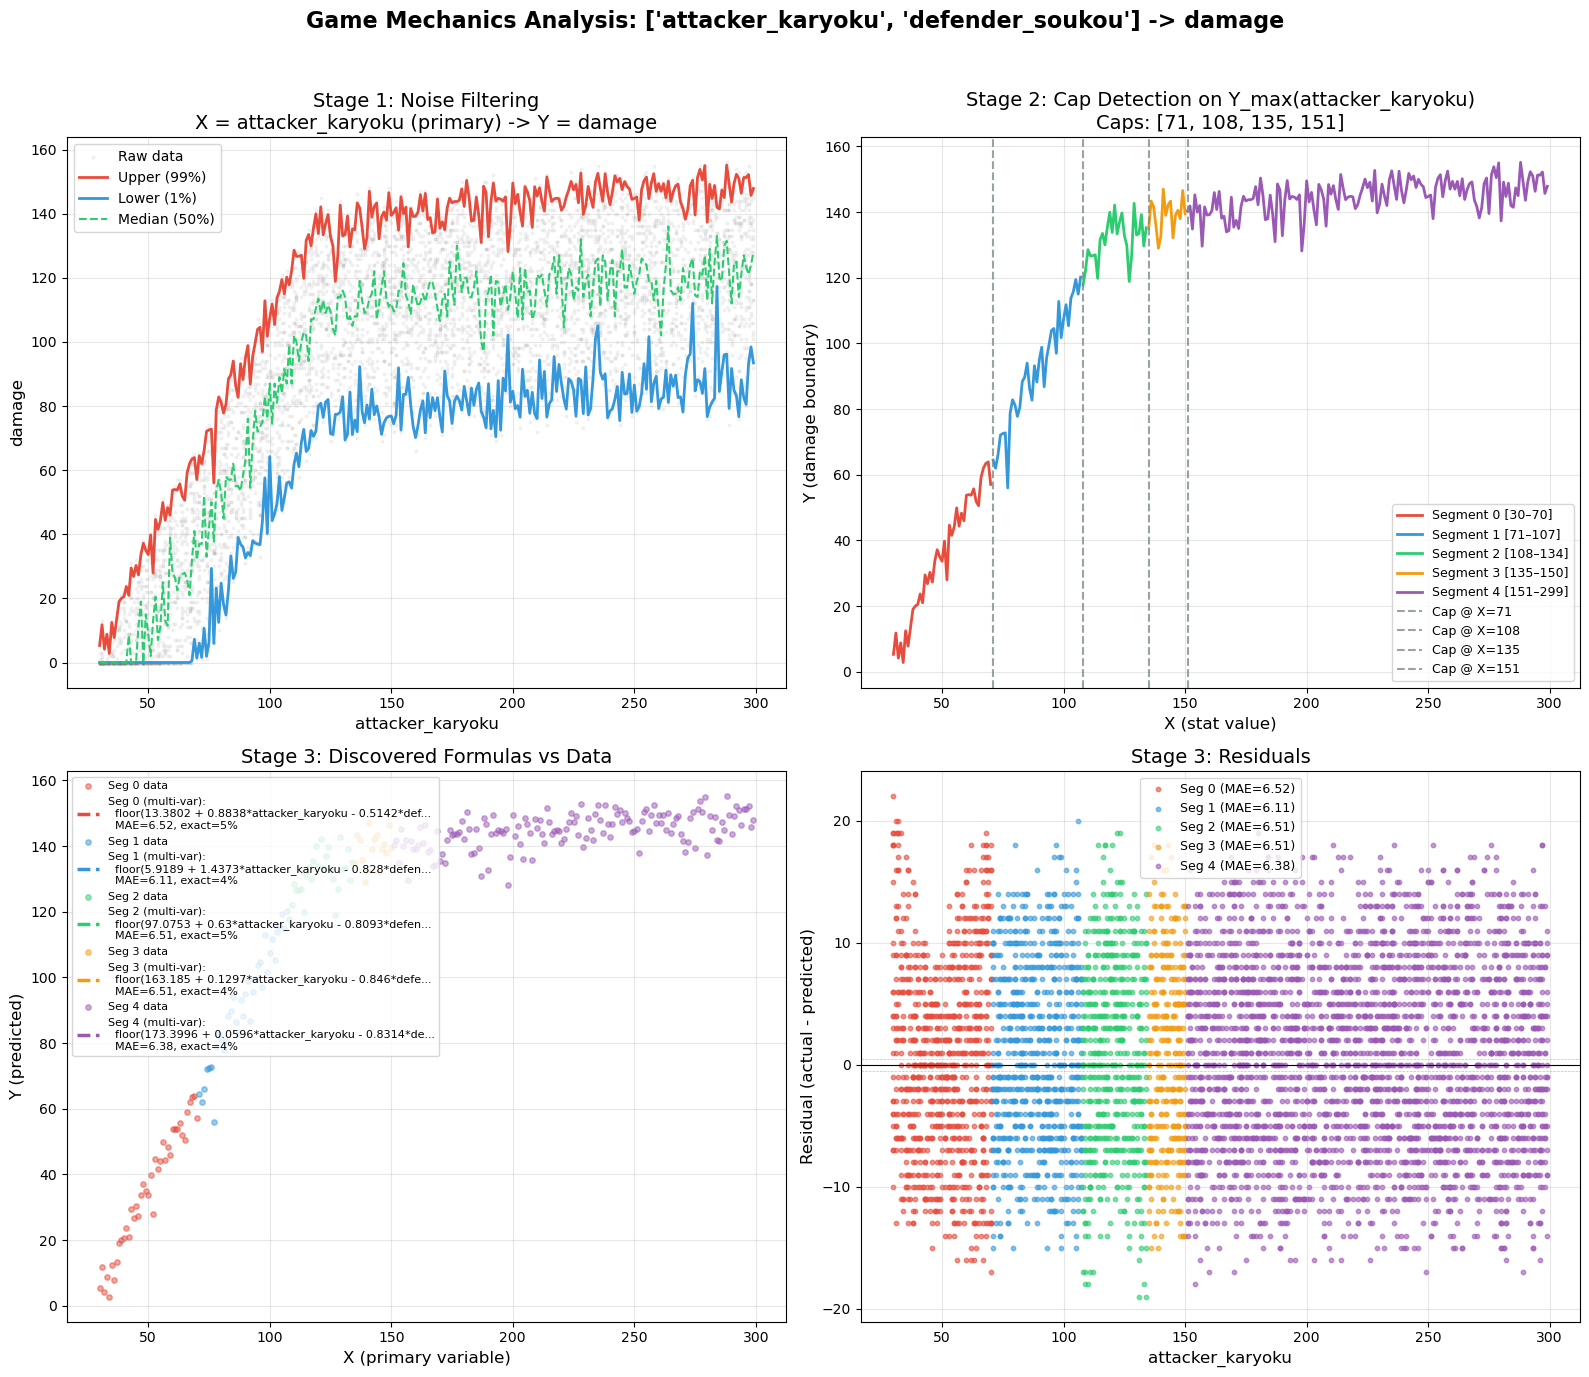

Plot saved to: C:\Users\ogu-h\Documents\Github\FUSOU\packages\fusou-datasets\examples\output/multi_var_analysis.png

  Both demos complete!


In [8]:
if __name__ == "__main__":
    run_single_variable_demo()
    run_multi_variable_demo()

    print()
    print("=" * 70)
    print("  Both demos complete!")
    print("=" * 70)